In [28]:
df.shape

(2000, 32)

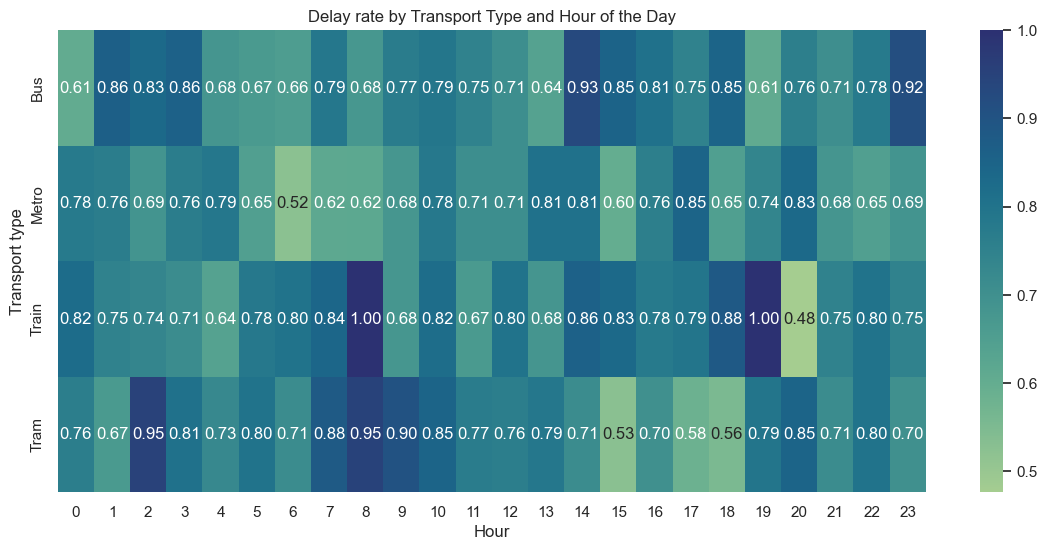

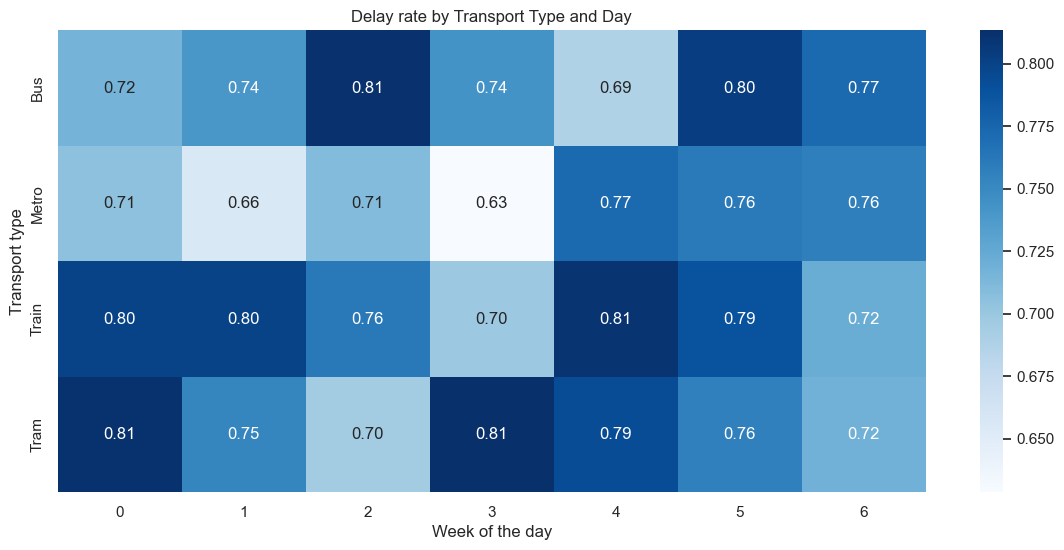

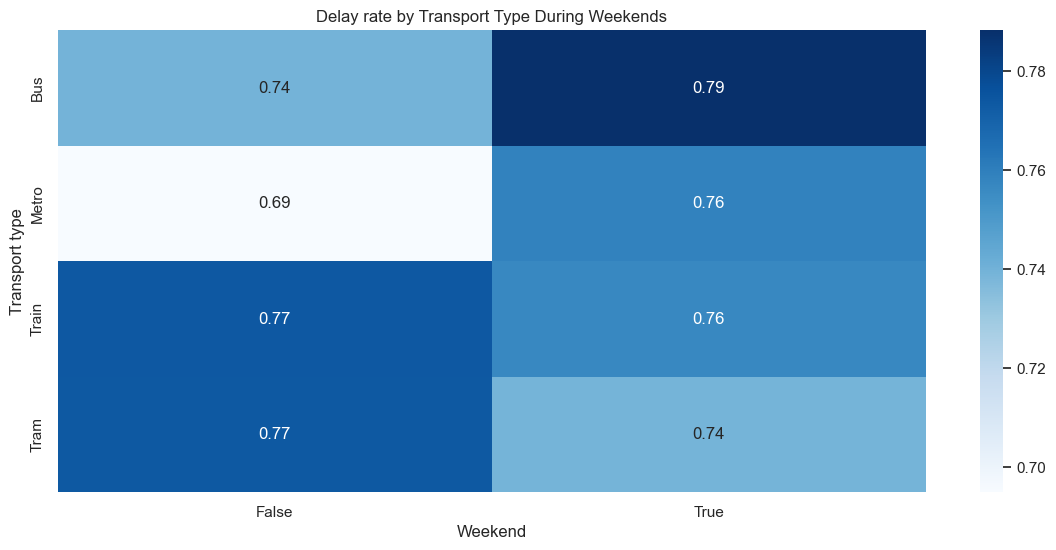

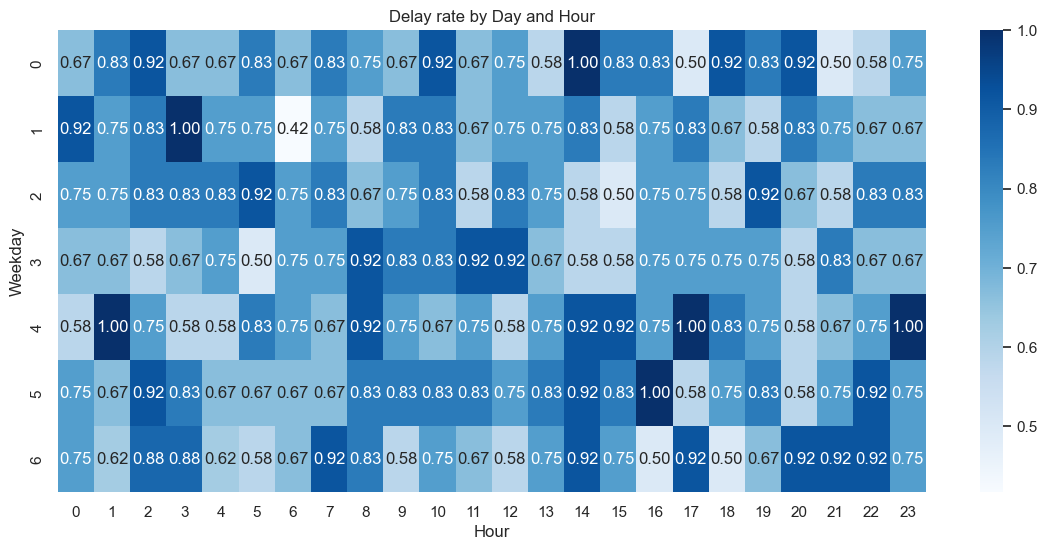

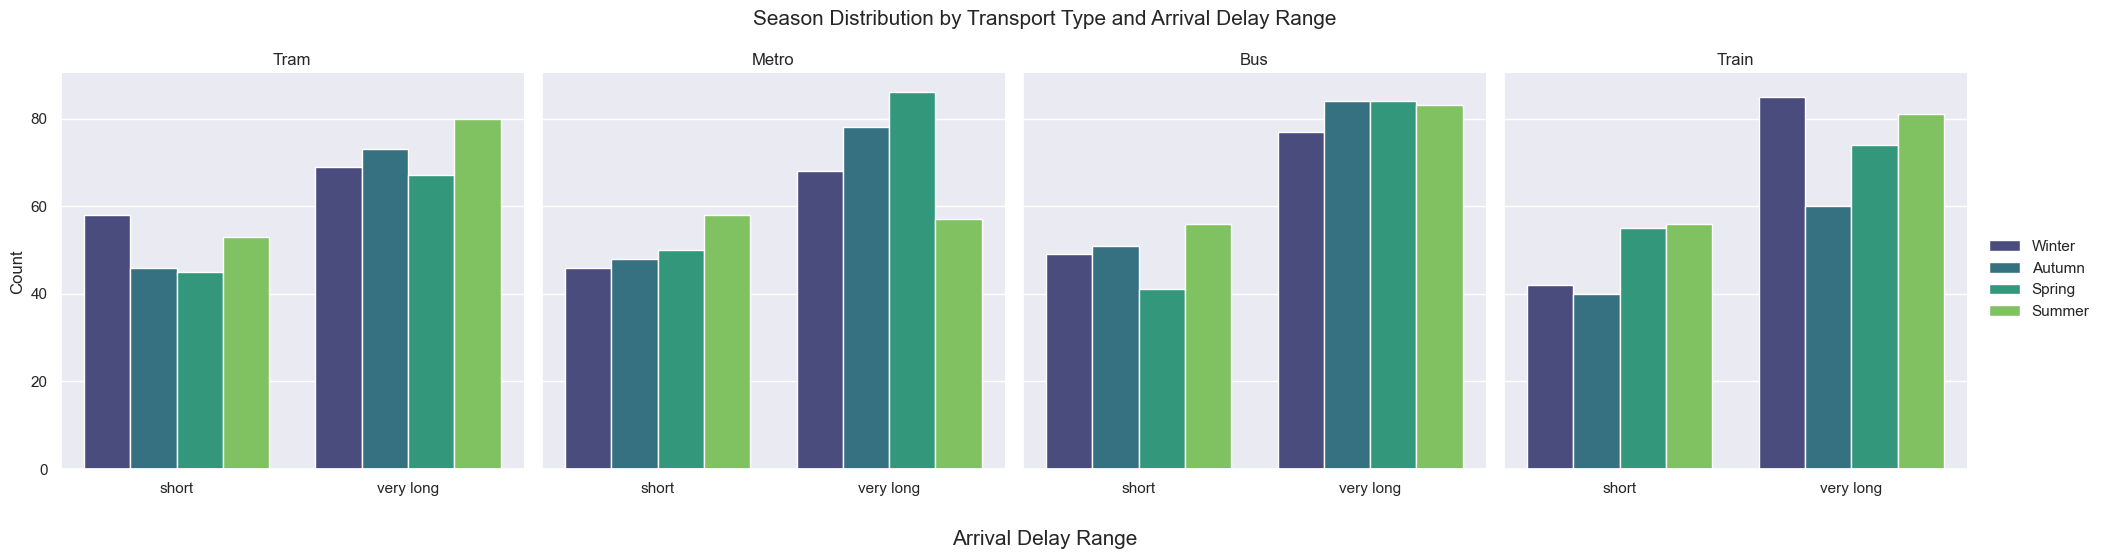

In [38]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")   # or "ticks", or "dark" — any non-grid style

# Import data
df = pd.read_csv('public_transport_delays.csv')

# Create a new column melting_snow (if clear & < 10 C, melts
df['melting_snow'] = np.where((df['temperature_C'] <= 10) & (df['weather_condition'] == 'Clear'), 'melting', 'no melting')

# Create a new column called 'delay_range'
df['delay_range'] = np.where(
                            (df['actual_arrival_delay_min'] <= 10) & (df['actual_arrival_delay_min'] <= 20), 
                             'short','very long')

# To confirm the threshold of delayed (5 min above considered delayed)
df.groupby('delayed')['actual_arrival_delay_min'].describe()

# Change the data type of date and time
df['date'] = pd.to_datetime(df['date'])
df['hour'] = pd.to_datetime(df['time'], format = '%H:%M:%S')

# Extract hour,day,month and create new columns
df['hour'] = df['hour'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

# To confirm is 0 == Monday in Python
pd.Timestamp('2026-07-27').dayofweek

# To check if our data 0 == Monday
df['weekday_check'] = pd.to_datetime(df['date']).dt.dayofweek

# Compare our data with python if manday python == monday data
df[['weekday', 'weekday_check']].head(10)

# Extract digits in route_id, convert the data into int
df['route'] = df['route_id'].str.extract(r'(\d+)')
df['route'] = df['route'].astype(int)

# Plot a heatmap of the average delay rate by transport type and hour of the day
plt.figure(figsize = (14,6))
heatmap_1 = df.pivot_table(index='transport_type', 
                   columns='hour', 
                   values='delayed',
                   aggfunc='mean')
heat_1 = sns.heatmap(heatmap_1, annot=True, fmt = '.2f', cmap='crest')
heat_1.set(xlabel = 'Hour', 
           ylabel = 'Transport type', 
           title = 'Delay rate by Transport Type and Hour of the Day')
sns.set_theme(palette="crest")
plt.savefig('heatmap_hour.png', dpi=300, bbox_inches='tight')

# Weekday vs weekend comparison
df['is_weekend'] = df['weekday'].isin([5, 6])
df.groupby('is_weekend')['delayed'].mean()

# Plot a heatmap of the average delay rate by transport type and day of the week
heatmap_2 = df.pivot_table(index='transport_type', 
                              columns='weekday', 
                              values='delayed', 
                              aggfunc='mean')
plt.figure(figsize = (14,6))
heat_2 = sns.heatmap((heatmap_2), annot = True, fmt ='.2f' , cmap = 'Blues')
heat_2.set(xlabel = 'Week of the day', 
           ylabel = 'Transport type', 
           title = 'Delay rate by Transport Type and Day')
plt.savefig('heatmap_weekday.png', dpi=300, bbox_inches='tight')

# Plot a heatmap to compare average delay rate on weekends and weekdays
heatmap_3 = df.pivot_table(index='transport_type', 
                              columns='is_weekend', 
                              values='delayed', 
                              aggfunc='mean')
plt.figure(figsize = (14,6))
heat_3 = sns.heatmap((heatmap_3), annot = True, fmt ='.2f' , cmap = 'Blues')
heat_3.set(xlabel = 'Weekend',
           ylabel = 'Transport type', 
           title = 'Delay rate by Transport Type During Weekends')
plt.savefig('heatmap_weekend.png', dpi=300, bbox_inches='tight')

# Plot a heatmap of the average delay rate by weekday and hour
plt.figure(figsize = (14,6))
heatmap_4 = df.pivot_table(index='weekday', 
                   columns='hour', 
                   values='delayed',
                   aggfunc='mean')
heat_4 = sns.heatmap(heatmap_4, annot=True, fmt = '.2f', cmap='Blues')
heat_4.set(xlabel = 'Hour', 
           ylabel = 'Weekday', 
           title = 'Delay rate by Day and Hour')


# Plot a bar chart to study how seasons and transport type affect the delay range (long/short)
g = sns.catplot(
    data = df,
    x = 'delay_range',
    hue = 'season',
    col = 'transport_type',
    kind = 'count',
    palette = 'viridis'
)
g.set(
    xlabel = 'Arrival Delay range', 
    ylabel = 'Count',
    title = 'Season Distribution by Transport Type and Delay Range')

# Remove the individual subplot titles (currently repeating 4x)
g.set_titles('{col_name}') 

# Remove legend title
g._legend.set_title('')# shows just "Bus", "Metro", etc. instead of the long repeated title

# Add ONE overall title, centered above all subplots
g.figure.suptitle('Season Distribution by Transport Type and Arrival Delay Range', y=1.05, fontsize = 15)

# Remove individual x-axis labels, add ONE centered x-axis label instead
g.set_axis_labels('', 'Count')  # Blank x-label per subplot
g.figure.text(0.5, -0.02, 'Arrival Delay Range', ha='center', fontsize=15)  # one centered label

plt.show()


In [39]:
df['temperature_C'].corr(df['actual_arrival_delay_min'])

-0.03994364743896487

Accuracy: 0.7375
              precision    recall  f1-score   support

           0       0.57      0.04      0.07       106
           1       0.74      0.99      0.85       294

    accuracy                           0.74       400
   macro avg       0.66      0.51      0.46       400
weighted avg       0.70      0.74      0.64       400



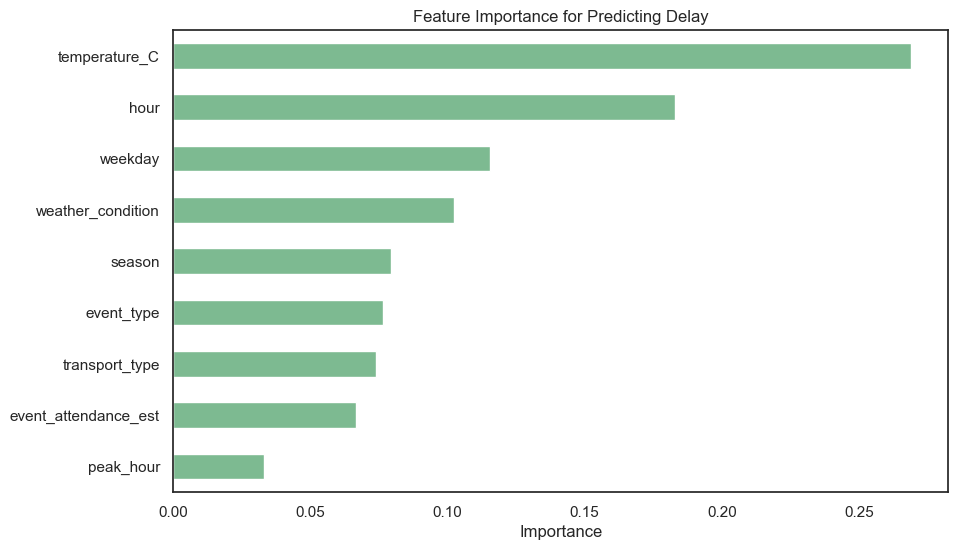

Importances: temperature_C           0.269065
hour                    0.183020
weekday                 0.115443
weather_condition       0.102525
season                  0.079466
event_type              0.076638
transport_type          0.073842
event_attendance_est    0.066747
peak_hour               0.033253
dtype: float64
Logistic coefficient: event_type              0.044539
weekday                 0.021044
peak_hour               0.016484
transport_type          0.013226
event_attendance_est    0.011246
weather_condition       0.001709
hour                   -0.024949
season                 -0.032869
temperature_C          -0.038607
dtype: float64


In [44]:
# To estimate the importance ranking of each variable

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_style("white")
# Select the features you want to use
features = ['weather_condition', 'season', 'hour', 'event_type', 'event_attendance_est', 'transport_type', 
            'temperature_C', 'peak_hour', 'weekday']  # adjust to your actual column names

X = df[features].copy()
y = df['delayed']

# Encode categorical (text) columns into numbers
categorical_cols = X.select_dtypes(include='object').columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le  # save encoders in case you need to decode later

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Feature Importance for Predicting Delay')
plt.gca().invert_yaxis()
plt.savefig('importance.png', dpi=300, bbox_inches='tight')

plt.show()
print('Importances:', importances)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic regression benefits from scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Coefficients show direction + magnitude of each feature's effect
coef = pd.Series(logreg.coef_[0], index=features).sort_values(ascending=False)
print('Logistic coefficient:' , coef)

In [46]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.05      0.09       106
           1       0.74      0.99      0.85       294

    accuracy                           0.74       400
   macro avg       0.73      0.52      0.47       400
weighted avg       0.74      0.74      0.65       400



In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trip_id                     2000 non-null   object        
 1   date                        2000 non-null   datetime64[ns]
 2   time                        2000 non-null   object        
 3   transport_type              2000 non-null   object        
 4   route_id                    2000 non-null   object        
 5   origin_station              2000 non-null   object        
 6   destination_station         2000 non-null   object        
 7   scheduled_departure         2000 non-null   object        
 8   scheduled_arrival           2000 non-null   object        
 9   actual_departure_delay_min  2000 non-null   int64         
 10  actual_arrival_delay_min    2000 non-null   int64         
 11  weather_condition           2000 non-null   object      